# Predict on test.csv

This notebook loads the trained RandomForest model from `project.ipynb` and uses it to generate predictions for `test.csv`, then writes a Kaggle-style submission file.

**Run `project.ipynb` first** so `rf_pruned.joblib` and `preprocessing_state.joblib` exist in this folder.

In [23]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
#load the test data
test_df = pd.read_csv(r"D:\SchoolCoding\Data3402\Data3402-TabularKaggleProject\Dataset\test.csv")

#save the IDs before we drop them - we need them for the submission file
test_ids = test_df["ID"].copy()

print("test shape:", test_df.shape)
test_df.head()

test shape: (75818, 370)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38
0,2,2,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40532.10
1,5,2,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45486.72
2,6,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46993.95
3,7,2,24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,187898.61
4,9,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73649.73


In [16]:
#load the trained model and the preprocessing column lists
#use absolute paths so it doesnt matter where the kernel was started from
ARTIFACTS_DIR = r"D:\SchoolCoding\Data3402\Data3402-TabularKaggleProject\Programfiles"

rf    = joblib.load(ARTIFACTS_DIR + r"\rf_pruned.joblib")
state = joblib.load(ARTIFACTS_DIR + r"\preprocessing_state.joblib")

print("zero-sum cols to drop:  ", len(state["zero_cols"]))
print("low-variance cols to drop:", len(state["low_var_cols"]))
print("top features to keep:    ", len(state["top_features"]))

zero-sum cols to drop:   34
low-variance cols to drop: 63
top features to keep:     76


In [17]:
#apply the same cleaning we did to train.csv: drop ID, drop the dead/low-variance columns,
#then keep only the top features the model was trained on
test_clean = test_df.drop(columns=["ID"])
test_clean = test_clean.drop(columns=state["zero_cols"], errors="ignore")
test_clean = test_clean.drop(columns=state["low_var_cols"], errors="ignore")
test_clean = test_clean[state["top_features"]]

print("cleaned test shape:", test_clean.shape)

cleaned test shape: (75818, 76)


In [18]:
#predict_proba returns [prob_class_0, prob_class_1] - we want class 1 (unsatisfied customer)
test_proba = rf.predict_proba(test_clean)[:, 1]
print("made", len(test_proba), "predictions")
print("predicted positive rate:", round((test_proba > 0.5).mean(), 4))

made 75818 predictions
predicted positive rate: 0.0254


In [19]:
#build the submission dataframe - matches the format of sample_submission.csv
submission = pd.DataFrame({"ID": test_ids, "TARGET": test_proba})
submission.head(10)

,ID,TARGET
0,2,0.130
1,5,0.005
2,6,0.000
3,7,0.000
4,9,0.000
5,11,0.165
6,12,0.015
7,15,0.020
8,16,0.015
9,17,0.005


In [20]:
#write the final csv to the Programfiles folder so it lands next to the notebook
submission_path = ARTIFACTS_DIR + r"\submission.csv"
submission.to_csv(submission_path, index=False)
print("wrote", submission_path, "with", len(submission), "rows")

wrote D:\SchoolCoding\Data3402\Data3402-TabularKaggleProject\Programfiles\submission.csv with 75818 rows


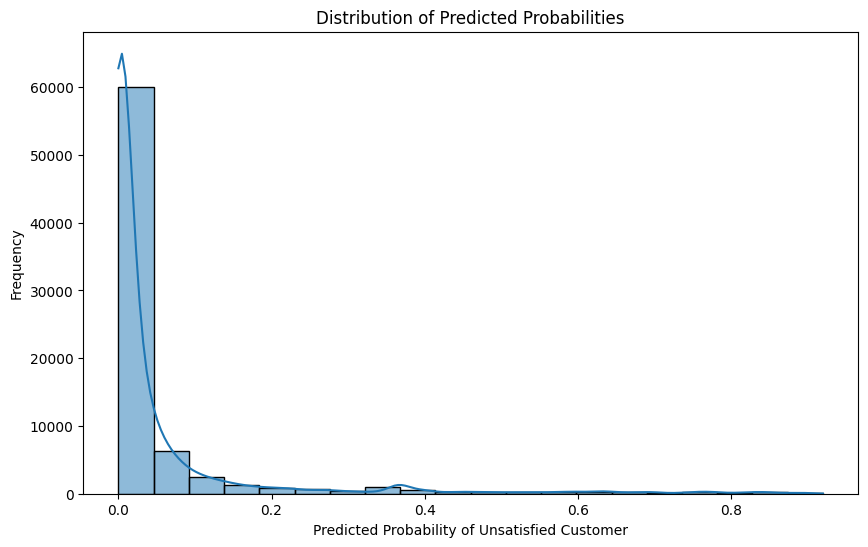

In [31]:
#lets look at the histpgram of the predicted probabilities to see how confident the model is in its predictions
df = pd.read_csv('submission.csv')
plt.figure(figsize=(10, 6))
sns.histplot(df['TARGET'], bins=20, kde=True)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Predicted Probability of Unsatisfied Customer')
plt.ylabel('Frequency')
plt.show()

# Result
generally the customers were predicted with low confidence - most of the probabilities are clustered around 0.1-0.3, which makes sense given the class imbalance in the training data (only about 20% unsatisfied customers)